In [1]:
!pip install confluent-kafka


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from confluent_kafka import Consumer
import re
import pandas as pd
import os

os.makedirs("data/ratings", exist_ok=True)

# Kafka consumer config
conf = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'ratings-consumer',
    'auto.offset.reset': 'latest'  # or 'earliest' to only get old messages
}

consumer = Consumer(conf)
consumer.subscribe(['movielog8'])

messages = []
max_messages = 10000000   # adjust based on how much you want to pull

while len(messages) < max_messages:
    msg = consumer.poll(1.0)
    if msg is None:
        continue
    if msg.error():
        print("Consumer error: {}".format(msg.error()))
        continue
    messages.append(msg.value().decode('utf-8'))

consumer.close()

print(f"Pulled {len(messages)} messages from Kafka")

Pulled 10000000 messages from Kafka


In [3]:
def parse_rating_line(line):
    try:
        # Example: 2025-09-18T20:39:43,19832,GET /rate/saving+private+ryan+1998=4
        timestamp, user_id, request = line.split(",", 2)
        match = re.search(r"/rate/(.+)=(\d+)", request)
        if match:
            movie_id = match.group(1)  
            rating = int(match.group(2))
            return {
                "timestamp": timestamp,
                "user_id": int(user_id),
                "movie_id": movie_id,
                "rating": rating
            }
    except Exception:
        return None

parsed_ratings = list(filter(None, (parse_rating_line(l) for l in messages)))
ratings_df = pd.DataFrame(parsed_ratings)
ratings_df.head()

,timestamp,user_id,movie_id,rating
0,2025-09-22T04:54:29,40760,how+to+train+your+dragon+2010,3
1,2025-09-22T04:54:36,24627,conspiracy+of+torture+1969,3
2,2025-09-22T04:54:37,81231,big+shots+funeral+2001,4
3,2025-09-22T04:54:43,104100,bride+of+the+monster+1955,2
4,2025-09-22T04:54:46,113561,desert+flower+2009,3


In [4]:
ratings_df["timestamp"] = pd.to_datetime(
    ratings_df["timestamp"], 
    errors="coerce",              #rare cases where seconds are missing
    infer_datetime_format=True,   
)
ratings_df.to_parquet("data/ratings/ratings.parquet", index=False)

/var/folders/36/75lxg8gj5dl89yv51_hjs7fr0000gn/T/ipykernel_34235/1172730046.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ratings_df["timestamp"] = pd.to_datetime(


In [5]:
invalid_rows = ratings_df[ratings_df["timestamp"].isna()]
print("Invalid rows:", len(invalid_rows))
invalid_rows.head()

Invalid rows: 1089


,timestamp,user_id,movie_id,rating
7,NaT,129522,deceiver+1997,3
8,NaT,43478,babes+in+arms+1939,3
71,NaT,102233,the+englishman+who+went+up+a+hill+but+came+dow...,1
76,NaT,31359,the+jungle+book+1994,5
89,NaT,147788,twister+1996,4


In [6]:

# Drop any invalid ones before checking
valid_ts = ratings_df["timestamp"].dropna()

min_ts = valid_ts.min()
max_ts = valid_ts.max()

print("📉 Earliest timestamp:", min_ts)
print("📈 Latest timestamp:", max_ts)

num_ratings = len(ratings_df)
print(f"Total ratings: {num_ratings}")

📉 Earliest timestamp: 2025-07-25 15:53:38
📈 Latest timestamp: 2025-09-23 03:17:36
Total ratings: 62071


In [7]:
def parse_watch_line(line):
    try:
        ts, user_id, request = line.split(",", 2)
        match = re.search(r"/data/m/(.+)/(\d+)\.mpg", request)
        if match:
            return {
                "timestamp": ts,
                "user_id": int(user_id),
                "movie_id": match.group(1), 
                "minute": int(match.group(2))
            }
    except:
        return None

watch_events = list(filter(None, (parse_watch_line(l) for l in messages)))
watches_df = pd.DataFrame(watch_events)
watches_df["timestamp"] = pd.to_datetime(watches_df["timestamp"], errors="coerce")
watches_df.head()

,timestamp,user_id,movie_id,minute
0,2025-09-22 04:54:29,79924,up+2009,43
1,2025-09-22 04:54:29,131556,mad+bastards+2010,74
2,2025-09-22 04:54:29,113619,dream+2008,83
3,2025-09-22 04:54:29,1003,dr.+no+1962,60
4,2025-09-22 04:54:29,102556,the+incredible+hulk+2008,109


In [8]:
collapsed = (
    watches_df.groupby(["user_id", "movie_id"])
    .agg(
        timestamp_start=("timestamp", "min"),
        timestamp_end=("timestamp", "max"),
        minutes_watched=("minute", "nunique")
    )
    .reset_index()
)

collapsed.head()

,user_id,movie_id,timestamp_start,timestamp_end,minutes_watched
0,3,first+target+2000,2025-09-22 08:05:40,2025-09-22 09:39:51,43
1,3,more+dead+than+alive+1969,2025-09-23 00:39:28,2025-09-23 02:18:44,50
2,3,my+neighbor+totoro+1988,2025-09-22 11:21:53,2025-09-22 12:48:59,36
3,3,post+tenebras+lux+2012,2025-09-22 20:37:11,2025-09-22 22:33:25,57
4,6,asfalto+2000,2025-09-23 03:00:07,2025-09-23 03:00:07,1


In [9]:
import os
os.makedirs("data/watches", exist_ok=True)

collapsed.to_parquet("data/watches/watches.parquet", index=False)
print("Saved watches.parquet with shape:", collapsed.shape)

Saved watches.parquet with shape: (192444, 5)


In [10]:
watches = pd.read_parquet("data/watches/watches.parquet")
watches.head()

,user_id,movie_id,timestamp_start,timestamp_end,minutes_watched
0,3,first+target+2000,2025-09-22 08:05:40,2025-09-22 09:39:51,43
1,3,more+dead+than+alive+1969,2025-09-23 00:39:28,2025-09-23 02:18:44,50
2,3,my+neighbor+totoro+1988,2025-09-22 11:21:53,2025-09-22 12:48:59,36
3,3,post+tenebras+lux+2012,2025-09-22 20:37:11,2025-09-22 22:33:25,57
4,6,asfalto+2000,2025-09-23 03:00:07,2025-09-23 03:00:07,1


In [11]:
print(watches["minutes_watched"].describe())

count    192444.000000
mean         51.454735
std          21.828861
min           1.000000
25%          40.000000
50%          52.000000
75%          64.000000
max         678.000000
Name: minutes_watched, dtype: float64


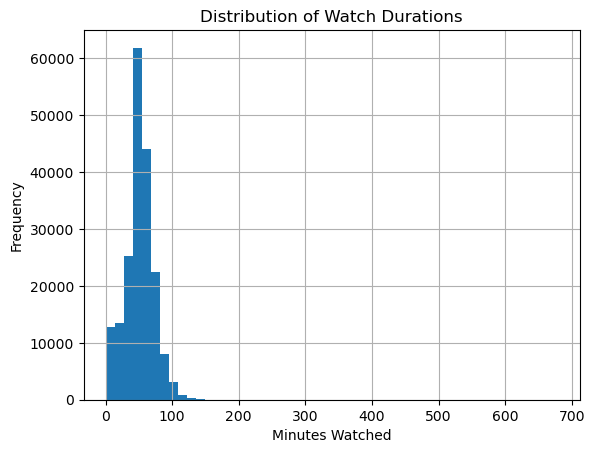

In [12]:
import matplotlib.pyplot as plt

watches["minutes_watched"].hist(bins=50)
plt.xlabel("Minutes Watched")
plt.ylabel("Frequency")
plt.title("Distribution of Watch Durations")
plt.show()

In [13]:
interaction_counts = watches.groupby("user_id")["movie_id"].count()
print("Avg movies per user:", interaction_counts.mean())
print("Max movies by a user:", interaction_counts.max())

movie_counts = watches.groupby("movie_id")["user_id"].count()
print("Avg users per movie:", movie_counts.mean())
print("Max users for a movie:", movie_counts.max())

Avg movies per user: 2.7079997185675087
Max movies by a user: 26
Avg users per movie: 8.144054168429962
Max users for a movie: 1192


In [14]:
import requests
import pandas as pd
import os

BASE_URL = "http://128.2.220.241:8080"
os.makedirs("data/meta", exist_ok=True)

In [15]:
def fetch_movie(movie_id):
    url = f"{BASE_URL}/movie/{movie_id}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            data["movie_id"] = movie_id  
            return data
    except Exception as e:
        print(f"Error fetching {movie_id}: {e}")
    return None

# get unique movie_ids from watches & ratings
movie_ids = set(watches["movie_id"].unique()) | set(ratings_df["movie_id"].unique())

movies_data = [fetch_movie(mid) for mid in movie_ids]
movies_df = pd.DataFrame([m for m in movies_data if m])

movies_df.to_parquet("data/meta/movies.parquet", index=False)
print("Saved movies.parquet with shape:", movies_df.shape)

Saved movies.parquet with shape: (23649, 24)


In [19]:
def fetch_user(user_id):
    url = f"{BASE_URL}/user/{user_id}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            return resp.json()
    except Exception as e:
        print(f"Error fetching {user_id}: {e}")
    return None

# get unique users from watches & ratings
user_ids = set(watches["user_id"].unique()) | set(ratings_df["user_id"].unique())

users_data = [fetch_user(uid) for uid in user_ids]
users_df = pd.DataFrame([u for u in users_data if u])

users_df.to_parquet("data/meta/users.parquet", index=False)
print("Saved users.parquet with shape:", users_df.shape)

Saved users.parquet with shape: (71121, 4)


In [20]:
print(movies_df.head(2))
print(users_df.head(2))

                        id  tmdb_id    imdb_id               title  \
0              secret+2007    20342  tt1037850              Secret   
1  halloweentown+high+2004    34560  tt0414078  Halloweentown High   

       original_title  adult  \
0              不能說的秘密  False   
1  Halloweentown High  False   

                               belongs_to_collection budget  \
0                                                 {}      0   
1  {'id': 87252, 'name': 'Halloweentown Collectio...      0   

                                              genres  \
0  [{'id': 14, 'name': 'Fantasy'}, {'id': 18, 'na...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 35, '...   

                                            homepage  ...  \
0                                               null  ...   
1  http://disneydvd.disney.go.com/halloweentown-h...  ...   

                                production_companies  \
0  [{'name': 'Sil-Metropole Organisation', 'id': ...   
1  [{'name': 'Reel FX Creative Studio